# Model comparison — overview & scorecard

Entry point for **decision making**: effort, pipeline outcomes, a cross-dimension KPI scorecard comparing the models on one screen, and a ranking of every run from best to worst. Detailed evidence lives in `10_build`, `20_tests_coverage` and `30_code_metrics`. Iterations are independent samples; only iterations 1–6 are included.

In [1]:
STORY_ID = "CPD-LC-001-003"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
# Clear the per-session label cache and warning list first: re-running this
# cell after dropping new results into the trees would otherwise reuse stale
# model labels and count the same load warning once per re-run.
tdd.reset_caches()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
if not MODELS:
    print(f"no results found for {STORY_ID!r}; stories present in the result "
          f"trees: {tdd.discover_stories()}")
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-003 | models: ['Kimi-K2.5', 'Qwen3.7-max']
palette: {'Kimi-K2.5': '#2a78d6', 'Qwen3.7-max': '#1baf7a'}


## Iteration summary (master table)

One row per (model, iteration): final build/test/coverage/metrics outcomes,
pipeline stage statuses and attempt counts. `NaN` = the stage produced no
canonical result for that cell. This table backs every chart below.

**Table columns** (one row per run; *final* = last execution of that run)

- `story`, `model`, `iteration` — the run's identity; `iteration` is one independent repetition (1–6) of the story by that model.
- `build_status`, `build_errors`, `build_warnings` — final build outcome (`success`/`failure`) and its compiler error / warning counts.
- `test_status`, `total_tests`, `passed`, `failed`, `skipped`, `pass_rate` — final test execution: overall status, test-method counts by outcome, and passed÷total.
- `line_rate`, `branch_rate` — line / branch coverage (0–1) of the run's final coverage report.
- `median_mi`, `min_mi` — median / worst maintainability index over the final snapshot's types; `max_cc`, `max_coupling`, `max_dit` — worst cyclomatic complexity, class coupling and inheritance depth; `n_types` — types analyzed; `pct_green_types` — share of types with all four flags GREEN; `source_lines`, `executable_lines` — code size totals.
- `tg_status`, `tg_test_methods` — test-generation stage status and emitted test methods; `cg_status`, `cg_files_created`, `cg_files_modified` — code-generation status and file footprint; `ref_status`, `ref_all_green`, `ref_loop_iterations`, `ref_n_remaining_violations` — refactoring status, whether every flag ended GREEN, loop passes spent, violations left.
- `build_attempts`, `test_attempts`, `metrics_attempts` — executions recorded per result tree for the run (1 + retries = effort).

In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
display(summ.round(3))

,story,model,iteration,build_status,build_errors,build_warnings,test_status,total_tests,passed,failed,skipped,pass_rate,line_rate,branch_rate,median_mi,min_mi,max_cc,max_coupling,max_dit,n_types,pct_green_types,source_lines,executable_lines,tg_status,tg_test_methods,...,build_failed_execs,build_errors_burned,build_peak_errors,build_first_pass,test_execs,attempts_to_green,test_failures_burned,red_first,test_methods,tests_per_intent,layer_coverage,layer_balance,tests_Domain,tests_Application,tests_Infrastructure,tests_Presentation,metrics_snapshots,worst_coupling_drop,green_share_gain,min_mi_gain,e2e_execs,e2e_attempts_to_pass,e2e_probe_depth,e2e_probe_pass_rate,e2e_infra_failures
0,CPD-LC-001-003,Kimi-K2.5,1,success,0,0,success,87,87,0,0,1.000,0.692,0.850,71.0,50,16,23,1,50,0.840,1318,191,success,25.0,...,1,10,10,False,6,2,1,True,87,2.900,1.0,0.0,51,13,8,15,3,0,0.000,0,4,4,1,1.0,0
1,CPD-LC-001-003,Kimi-K2.5,2,success,0,2,success,87,87,0,0,1.000,0.640,0.857,72.0,52,9,17,1,51,0.843,1243,192,success,30.0,...,6,44,10,False,9,2,2,True,87,2.900,1.0,0.0,51,13,8,15,2,0,0.023,2,6,6,1,1.0,2
2,CPD-LC-001-003,Kimi-K2.5,3,success,0,0,success,87,87,0,0,1.000,0.711,0.750,72.5,52,8,20,1,50,0.860,1219,179,success,25.0,...,2,22,14,False,5,2,1,True,87,2.900,1.0,0.0,51,13,8,15,3,0,0.020,2,4,4,1,1.0,0
3,CPD-LC-001-003,Kimi-K2.5,4,success,0,0,success,87,87,0,0,1.000,0.720,0.800,72.5,52,8,20,1,50,0.840,1251,192,success,25.0,...,4,22,10,False,4,2,1,True,87,2.900,1.0,0.0,51,13,8,15,2,0,0.020,2,1,1,1,1.0,0
4,CPD-LC-001-003,Kimi-K2.5,5,success,0,2,success,87,87,0,0,1.000,0.692,0.889,72.0,55,10,22,1,55,0.855,1228,183,success,35.0,...,6,26,10,False,10,3,7,True,87,2.900,1.0,0.0,51,13,8,15,6,2,0.015,0,5,5,1,1.0,0
5,CPD-LC-001-003,Kimi-K2.5,6,success,0,0,success,88,88,0,0,1.000,0.691,0.850,72.0,50,15,20,1,50,0.820,1265,194,success,35.0,...,4,30,12,False,5,2,3,True,88,2.933,1.0,0.0,52,13,8,15,3,0,0.000,0,2,2,1,1.0,0
6,CPD-LC-001-003,Qwen3.7-max,1,success,0,2,success,88,88,0,0,1.000,0.689,0.765,71.0,51,10,21,1,53,0.868,1308,189,success,21.0,...,4,32,10,False,7,1,0,False,88,2.933,1.0,0.0,52,13,8,15,7,-1,0.025,0,2,1,1,1.0,0
7,CPD-LC-001-003,Qwen3.7-max,2,success,0,2,success,87,87,0,0,1.000,0.703,0.895,72.0,51,14,21,1,51,0.824,1242,185,success,25.0,...,3,30,10,False,3,1,0,False,87,2.900,1.0,0.0,51,13,8,15,3,-1,0.007,1,2,2,2,1.0,0
8,CPD-LC-001-003,Qwen3.7-max,3,success,0,0,success,87,87,0,0,1.000,0.707,0.875,73.0,52,10,20,1,50,0.860,1231,182,success,25.0,...,1,6,6,False,4,1,0,False,87,2.900,1.0,0.0,51,13,8,15,3,0,0.020,1,3,3,2,1.0,0
9,CPD-LC-001-003,Qwen3.7-max,4,success,0,0,failure,88,87,1,0,0.989,0.703,0.889,73.0,52,10,18,1,54,0.852,1261,183,success,25.0,...,0,0,0,True,5,1,1,False,88,2.933,1.0,0.0,52,13,8,15,7,4,0.006,1,1,1,1,1.0,0


## Data integrity gate

**Run this first on every new story.** It answers three questions before any
chart is trusted: did the runs *land* in the right place, is there evidence to
measure, and does each metric still carry signal?

- **Identity drift** — a run is addressed by `(story, model, iteration)`. The
  directory the harness created and the `"model"` field the agent wrote inside
  its JSON routinely disagree, and directories disagree between trees. All
  joins use `tdd.canonical_model`, so drift is absorbed; what this table shows
  is anything that *cannot* be reconciled — a genuinely misfiled result.
- **Evidence completeness** — share of the four result trees (build, test,
  metrics, e2e) that left a readable artifact for the run. A run scoring well
  on three pillars with no e2e evidence has not been verified the same way as
  one that has it, so completeness is reported, never folded into a score.
- **Signal check** — any metric that is constant or all-NA across the cohort
  cannot separate two models. That is a defect (a broken join, or a quantity
  the pipeline saturates), not a data point.


In [4]:
drift = tdd.audit_identity(STORY_ID)
ev = tdd.evidence(STORY_ID)
sig = tdd.discrimination(summ)

unreconciled = drift[~drift["reconciles"]] if not drift.empty else drift
incomplete = ev[ev["evidence_completeness"] < 1.0]
dead = sig[sig["status"].isin(["ABSENT", "ALL-NA", "CONSTANT"])]

print(f"identity   : {len(drift)} path/payload disagreements, "
      f"{len(unreconciled)} unreconcilable")
print(f"evidence   : {len(ev) - len(incomplete)}/{len(ev)} runs have all four trees")
print(f"signal     : {len(sig) - len(dead)}/{len(sig)} metrics discriminate")
print(f"load        : {len(tdd.load_warnings)} warnings")

if not unreconciled.empty:
    print("\nMISFILED RESULTS (canonical key cannot rescue these):")
    display(unreconciled.head(20))
if not incomplete.empty:
    print("\nRUNS MISSING EVIDENCE:")
    display(incomplete)

# Signal check, worst first: anything not "ok" needs a look before the charts.
order = {"ABSENT": 0, "ALL-NA": 1, "CONSTANT": 2, "WEAK": 3, "ok": 4}
display(sig.assign(_o=sig["status"].map(order))
           .sort_values(["_o", "family", "metric"])
           .drop(columns="_o")
           .reset_index(drop=True))


identity   : 0 path/payload disagreements, 0 unreconcilable
evidence   : 12/12 runs have all four trees
signal     : 19/24 metrics discriminate
load        : 0 warnings


,metric,family,provenance,status,distinct,na_share
0,e2e_probe_pass_rate,B behavioural,tool-measured,CONSTANT,1,0.000
1,evidence_completeness,E evidence,derived,CONSTANT,1,0.000
2,ref_all_green,Q quality,self-reported,CONSTANT,1,0.083
3,layer_balance,V verification,tool-measured,CONSTANT,1,0.000
4,layer_coverage,V verification,tool-measured,CONSTANT,1,0.000
5,e2e_infra_failures,B behavioural,tool-measured,WEAK,2,0.000
6,e2e_probe_depth,B behavioural,self-reported,WEAK,2,0.000
7,red_first,C convergence,tool-measured,WEAK,2,0.000
8,tests_per_intent,V verification,tool-measured,WEAK,2,0.000
9,e2e_attempts_to_pass,B behavioural,tool-measured,ok,6,0.000


## Effort: executions per iteration

Every retry the agent needed before moving on, per result tree. Taller bars =
more friction. Compare models at the same iteration position.

**Chart columns** — one panel per result tree (`build`, `test`, `metrics`): `iteration` (x) — run position 1–6; `executions` (y) — timestamped executions recorded in that tree for the run (1 + retries); bar color — model.

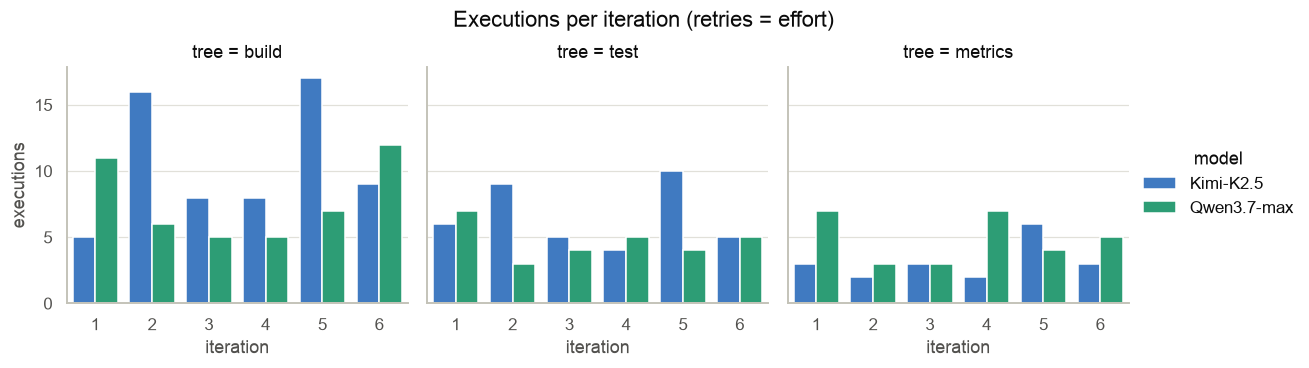

In [5]:
ac = pd.concat([
    tdd.attempt_counts(data["build"], "build"),
    tdd.attempt_counts(data["test"], "test"),
    tdd.attempt_counts(data["metrics_types"], "metrics"),
])
if ac.empty:
    print("No data for this section.")
else:
    g = sns.catplot(data=ac, kind="bar", x="iteration", y="n_attempts",
                    hue="model", col="tree", hue_order=HUE, palette=PAL,
                    height=3.2, aspect=1.1)
    g.set_axis_labels("iteration", "executions")
    g.figure.suptitle("Executions per iteration (retries = effort)", y=1.04)

## Effort distribution per model

Small samples (6 iterations/model), so every point is shown over the box.
A tight low box = the model converges with little friction.

**Chart columns** — one panel per result tree: `model` (x); `executions per iteration` (y) — the same per-run execution counts as above, pooled over iterations; box — median/IQR across runs; black dots — individual runs.

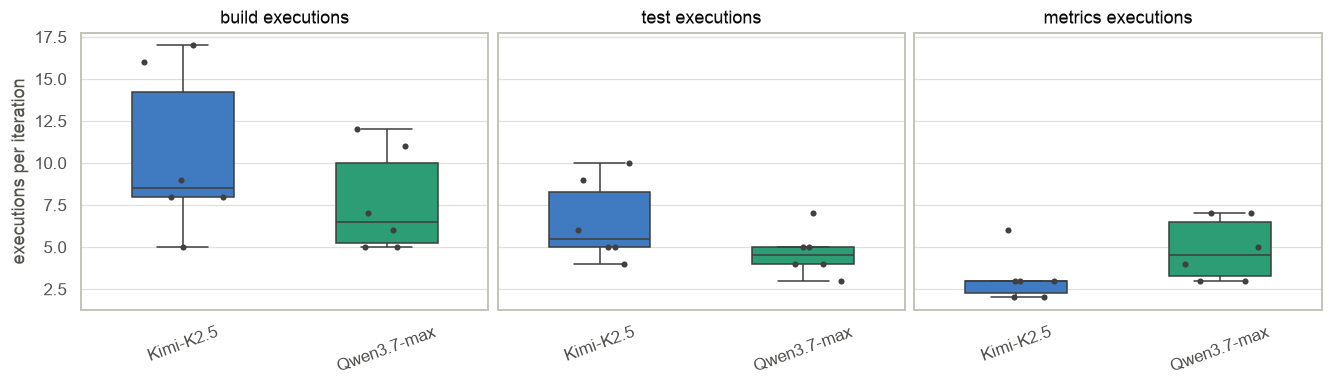

In [6]:
if ac.empty:
    print("No data for this section.")
else:
    trees = list(ac["tree"].unique())
    fig, axes = plt.subplots(1, len(trees), figsize=(4 * len(trees), 3.4), sharey=True)
    for ax, tree in zip(np.atleast_1d(axes), trees):
        sub = ac[ac["tree"] == tree]
        sns.boxplot(data=sub, x="model", y="n_attempts", hue="model", order=HUE,
                    hue_order=HUE, palette=PAL, legend=False, width=0.5,
                    showfliers=False, ax=ax)
        sns.stripplot(data=sub, x="model", y="n_attempts", order=HUE,
                      color=".25", size=4, jitter=0.2, ax=ax)
        ax.set_title(f"{tree} executions")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
    axes_flat = np.atleast_1d(axes)
    axes_flat[0].set_ylabel("executions per iteration")

## Pipeline stage outcomes per cell

One matrix per stage; each cell is (model, iteration). `S` = success,
`P` = partial, `F` = failure; gray = no result recorded.

**Chart columns** — one matrix per pipeline stage (`test-generation`, `code-generation`, `refactoring`): rows — model; columns — `iteration` (run 1–6); cell color + letter — the stage's reported status for that run (`S`uccess / `P`artial / `F`ailure; gray = no result file).

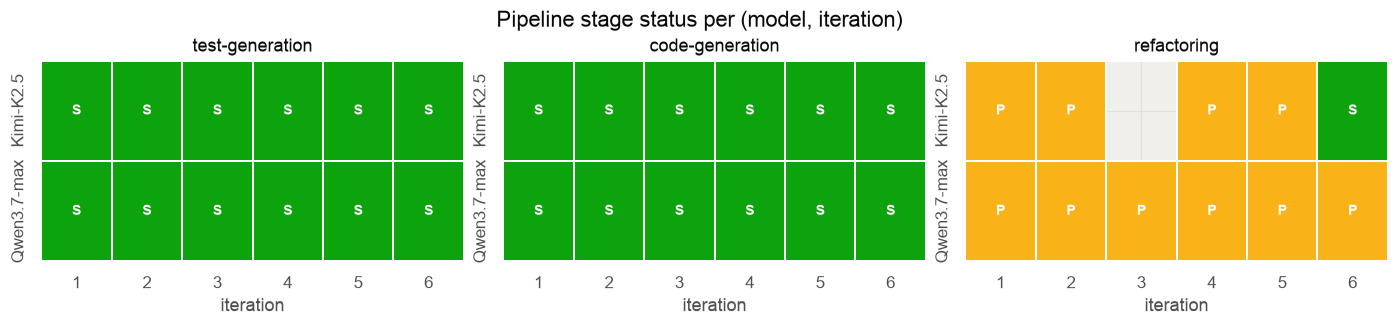

In [7]:
from matplotlib.colors import BoundaryNorm, ListedColormap

stages = data["stages"]
if stages.empty:
    print("No data for this section.")
else:
    order = ["test-generation", "code-generation", "refactoring"]
    code_map = {"failure": 0, "partial": 1, "success": 2}
    abbr = {"failure": "F", "partial": "P", "success": "S"}
    iters = sorted(stages["iteration"].unique())
    cmap = ListedColormap([tdd.STAGE_STATUS_COLORS["failure"],
                           tdd.STAGE_STATUS_COLORS["partial"],
                           tdd.STAGE_STATUS_COLORS["success"]])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    fig, axes = plt.subplots(1, len(order), figsize=(4.2 * len(order), 2.6))
    for ax, stage in zip(np.atleast_1d(axes), order):
        sub = stages[stages["stage"] == stage]
        grid = (sub.pivot(index="model", columns="iteration", values="status")
                   .reindex(index=HUE, columns=iters))
        sns.heatmap(grid.map(code_map.get), cmap=cmap, norm=norm, cbar=False,
                    annot=grid.map(lambda s: abbr.get(s, "")), fmt="",
                    linewidths=1, linecolor="white", ax=ax,
                    annot_kws={"fontsize": 9, "color": "white", "fontweight": "bold"})
        ax.set_facecolor("#f0efec")
        ax.set_title(stage)
        ax.set_ylabel("")
    fig.suptitle("Pipeline stage status per (model, iteration)", y=1.08)

## Refactoring: all-green achievement and loop cost

Left: how often the refactoring loop drove every metric flag to GREEN
(annotated with the raw fraction — n is small). Right: how many loop
iterations it took; points on the dashed line hit the budget ceiling.

**Chart columns** — left: `model` (x); `all-green rate` (y) — share of runs whose refactoring loop ended with every metric flag GREEN, annotated `achieved/runs`. Right: `model` (x); `loop iterations` (y) — refactoring loop passes reported per run (dots — runs; box — spread; dashed line — configured loop budget).

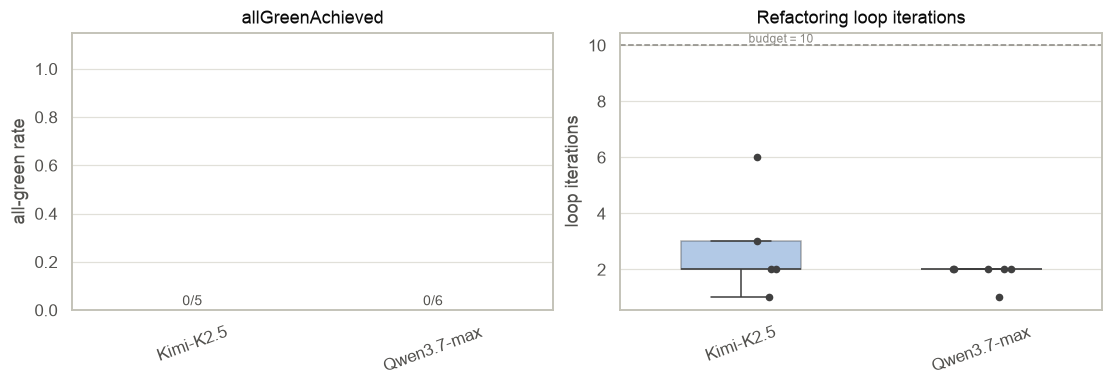

In [8]:
ref = data["stages"].query("stage == 'refactoring'") if not data["stages"].empty else data["stages"]
if ref.empty:
    print("No refactoring results.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

    ag = (ref.assign(all_green=ref["ref_all_green"].map({True: 1.0, False: 0.0}))
             .groupby("model")["all_green"].agg(rate="mean", achieved="sum", n="count")
             .reindex(HUE))
    sns.barplot(x=ag.index, y=ag["rate"], hue=ag.index, hue_order=HUE,
                palette=PAL, legend=False, ax=ax1)
    for i, (_, row) in enumerate(ag.iterrows()):
        ax1.text(i, row["rate"] + 0.02, f"{int(row['achieved'])}/{int(row['n'])}",
                 ha="center", fontsize=9, color=tdd.INK["secondary"])
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("all-green rate")
    ax1.set_xlabel("")
    ax1.set_title("allGreenAchieved")
    ax1.tick_params(axis="x", rotation=20)

    sns.boxplot(data=ref, x="model", y="ref_loop_iterations", hue="model",
                order=HUE, hue_order=HUE, palette=PAL, legend=False,
                width=0.5, showfliers=False, boxprops={"alpha": 0.4}, ax=ax2)
    sns.stripplot(data=ref, x="model", y="ref_loop_iterations", order=HUE,
                  color=".25", size=5, jitter=0.15, ax=ax2)
    ceiling = ref["ref_max_loop_iterations"].max()
    if pd.notna(ceiling):
        ax2.axhline(ceiling, ls="--", color=tdd.INK["muted"], lw=1)
        ax2.text(0.02, ceiling, f" budget = {int(ceiling)}", va="bottom",
                 fontsize=8, color=tdd.INK["muted"])
    ax2.set_ylabel("loop iterations")
    ax2.set_xlabel("")
    ax2.set_title("Refactoring loop iterations")
    ax2.tick_params(axis="x", rotation=20)

## KPI scorecard

All dimensions on one screen. Color = per-column min-max normalization,
oriented so **darker = better** (columns marked ↓ are inverted: lower raw
value is better). Numbers are the **raw** values — read those for decisions;
color only ranks the models per column.

Every column is **tool-measured**: it comes from a build log, a VSTest `.trx`,
a Cobertura report, a metrics snapshot or an e2e probe result — never from a
value an agent wrote about its own work. Columns describe the whole retry
path rather than the final execution, because the pipeline does not stop
until the build compiles and the tests are green, which makes any final-state
outcome constant across runs.

**Scorecard columns** (rows = models; every cell aggregates that model's runs)

- `failed builds ↓` — mean executions per run that did not compile.
- `errors burned ↓` — mean compiler errors fought through per run.
- `attempts to green ↓` — mean test executions until the first fully passing run.
- `red-first rate` — share of runs whose first test execution failed, as
  test-first development requires; a green first run means the tests followed
  the code.
- `line coverage`, `branch coverage` — mean final coverage rates (0–1).
- `tests / intent` — emitted test methods ÷ the story's confirmed intents,
  both counted from the `.trx` and `UserIntents/`.
- `layer balance` — how evenly test effort matched the per-layer intent
  distribution (1.0 = proportional).
- `median MI` — median over runs of the per-run median maintainability index.
- `% all-GREEN types` — mean share of types with all four metric flags GREEN.
- `coupling reduced` — mean fall in the worst type's class coupling between
  the first and last metrics snapshot.
- `e2e attempts ↓` — mean executions until the story first passed end-to-end
  against a real database and a running API.


,failed builds ↓,errors burned ↓,attempts to green ↓,red-first rate,line coverage,branch coverage,tests / intent,layer balance,median MI,% all-GREEN types,coupling reduced,e2e attempts ↓
model,,,,,,,,,,,,
Kimi-K2.5,3.833,25.667,2.167,1.0,0.691,0.833,2.906,0.0,72.0,0.843,0.333,3.667
Qwen3.7-max,2.833,22.333,1.000,0.0,0.703,0.849,2.911,0.0,72.0,0.851,0.667,1.833


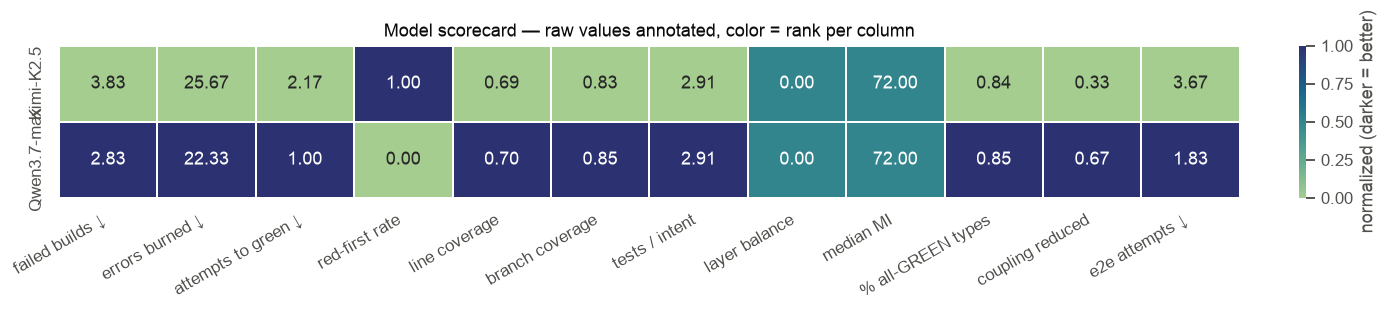

In [9]:
by_model = summ.groupby("model")
kpis = pd.DataFrame({
    "failed builds ↓": by_model["build_failed_execs"].mean(),
    "errors burned ↓": by_model["build_errors_burned"].mean(),
    "attempts to green ↓": by_model["attempts_to_green"].mean(),
    "red-first rate": by_model["red_first"].mean(),
    "line coverage": by_model["line_rate"].mean(),
    "branch coverage": by_model["branch_rate"].mean(),
    "tests / intent": by_model["tests_per_intent"].mean(),
    "layer balance": by_model["layer_balance"].mean(),
    "median MI": by_model["median_mi"].median(),
    "% all-GREEN types": by_model["pct_green_types"].mean(),
    "coupling reduced": by_model["worst_coupling_drop"].mean(),
    "e2e attempts ↓": by_model["e2e_attempts_to_pass"].mean(),
}).reindex(HUE)

norm = kpis.copy()
for col in norm:
    v = norm[col].astype(float)
    lo, hi = v.min(), v.max()
    n = (v - lo) / (hi - lo) if hi > lo else pd.Series(0.5, index=v.index)
    norm[col] = 1 - n if col.endswith("↓") else n

annot = kpis.map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}")
fig, ax = plt.subplots(figsize=(12.5, 2.6))
sns.heatmap(norm.astype(float), annot=annot, fmt="", cmap="crest",
            vmin=0, vmax=1, linewidths=1, linecolor="white",
            cbar_kws={"label": "normalized (darker = better)"}, ax=ax)
ax.set_facecolor("#f0efec")
ax.set_ylabel("")
ax.set_title("Model scorecard — raw values annotated, color = rank per column")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
display(kpis.round(3))


## Best run — all (model, iteration) runs ranked

Which single run of this story is the best? Every run is scored on three
pillars, each an equal-weight mean of its components (`PILLAR_WEIGHTS` sets
the pillar mix):

- **build** — final build succeeds ᵃ, few build errors ʳ, few build warnings ʳ, few build executions ʳ;
- **tests & coverage** — final pass rate ᵃ, line ᵃ and branch ᵃ coverage, confirmed-intents ratio ᵃ, few test executions until the first fully-green run ʳ;
- **refactoring & quality** — % all-GREEN types ᵃ, median MI ᵃ, worst-type MI ᵃ, worst-type threshold flags ᵃ (each metric's worst type mapped GREEN=1 / YELLOW=0.5 / RED=0), low worst-type coupling ʳ, all-green refactoring achieved ᵃ, few remaining violations ʳ, few refactoring loops ʳ, few metrics executions ʳ.

Normalization is two-tier, marked per component: **ᵃ = absolute anchor**
(0–1 rates/ratios used raw, MI÷100, the documented SQA thresholds) — fixed
before this cohort existed and comparable across stories; **ʳ = min–max
within these runs** (open-ended counts have no absolute scale; a flat column
counts 0.5 for everyone; ↓ = lower is better). Missing evidence scores 0 —
producing no result *is* a result. Quality components outnumber effort
components, so verified outcomes outweigh the cost of reaching them.
Self-reported stage statuses are never scored — only tool-measured artifacts
(the one stage metric used, all-green, is cross-checked by the violations
count).

Two weight-independent robustness checks accompany the score: `pareto` —
runs not dominated on all three pillars; only these can rank #1 under *any*
positive weighting (★ in the chart). `top1_share` / `rank_range` — how often
the run wins, and the ranks it spans, across a deterministic 120-point grid
of pillar weightings (each pillar 0.10–0.80 in 0.05 steps, summing to 1).

**Table columns** — row order/`rank` — best to worst by `composite` (the
weighted pillar mean); `build`, `tests & coverage`, `refactoring & quality`
— pillar scores (0–1); `pareto`, `top1_share`, `rank_range` — the robustness
checks above. Then the raw evidence: final build `build_status`,
`build_errors`, `build_warnings` and `build_attempts` (executions); final
`pass_rate`, `line_rate`, `branch_rate`; `intents_ratio` — test-generation's
confirmed intents ÷ the story's confirmed intents; `attempts_to_green` —
first fully-green test execution; `test_attempts` — all test executions
(context, unscored); `median_mi`, `min_mi`, `max_coupling`, `worst_flag` —
final-snapshot metric aggregates; `pct_green_types`; refactoring outcome
(`ref_all_green`, `ref_n_remaining_violations`, `ref_loop_iterations`);
`metrics_attempts`; `source_lines` — code size (context, unscored).

<>:139: SyntaxWarning: invalid escape sequence '\s'
<>:139: SyntaxWarning: invalid escape sequence '\s'
/var/folders/l8/xq7bdxm16pd2kd956l6t9mf00000gn/T/ipykernel_5939/677771318.py:139: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title("Runs ranked best \u2192 worst ($\star$ = Pareto-optimal)")


,model,iteration,composite,build,tests & coverage,refactoring & quality,behaviour,pareto,top1_share,rank_range,build_failed_execs,build_errors_burned,build_peak_errors,build_warnings,attempts_to_green,test_failures_burned,red_first,line_rate,branch_rate,tests_per_intent,layer_balance,median_mi,min_mi,max_coupling,worst_flag,pct_green_types,worst_coupling_drop,green_share_gain,min_mi_gain,e2e_attempts_to_pass,e2e_probe_depth,e2e_infra_failures,evidence_completeness,source_lines
rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Qwen3.7-max,4,0.824,1.000,0.575,0.720,1.000,True,1.0,1–1,0,0,0,0,1,1,False,0.703,0.889,2.933,0.0,73.0,52,18,0.875,0.852,4,0.006,1,1,1,0,1.0,1261
2,Kimi-K2.5,4,0.697,0.502,0.646,0.638,1.000,True,0.0,2–4,4,22,10,0,2,1,True,0.720,0.800,2.900,0.0,72.5,52,20,0.875,0.840,0,0.020,2,1,1,0,1.0,1251
3,Qwen3.7-max,3,0.688,0.735,0.597,0.642,0.778,True,0.0,2–5,1,6,6,0,1,0,False,0.707,0.875,2.900,0.0,73.0,52,20,0.875,0.860,0,0.020,1,3,2,0,1.0,1231
4,Qwen3.7-max,5,0.665,0.496,0.588,0.577,1.000,False,0.0,3–7,2,20,10,2,1,0,False,0.705,0.824,2.900,0.0,71.5,52,19,0.875,0.865,1,0.000,0,1,1,0,1.0,1244
5,Qwen3.7-max,1,0.647,0.398,0.576,0.614,1.000,False,0.0,3–7,4,32,10,2,1,0,False,0.689,0.765,2.933,0.0,71.0,51,21,0.875,0.868,-1,0.025,0,1,1,0,1.0,1308
6,Kimi-K2.5,3,0.623,0.464,0.636,0.641,0.750,True,0.0,4–9,2,22,14,0,2,1,True,0.711,0.750,2.900,0.0,72.5,52,20,0.875,0.860,0,0.020,2,4,1,0,1.0,1219
7,Kimi-K2.5,1,0.618,0.642,0.650,0.429,0.750,True,0.0,3–12,1,10,10,0,2,1,True,0.692,0.850,2.900,0.0,71.0,50,23,0.750,0.840,0,0.000,0,4,1,0,1.0,1318
8,Kimi-K2.5,6,0.589,0.423,0.602,0.499,0.833,False,0.0,6–11,4,30,12,0,2,3,True,0.691,0.850,2.933,0.0,72.0,50,20,0.750,0.820,0,0.000,0,2,1,0,1.0,1265
9,Qwen3.7-max,2,0.586,0.421,0.600,0.490,0.833,False,0.0,7–12,3,30,10,2,1,0,False,0.703,0.895,2.900,0.0,72.0,51,21,0.750,0.824,-1,0.007,1,2,2,0,1.0,1242


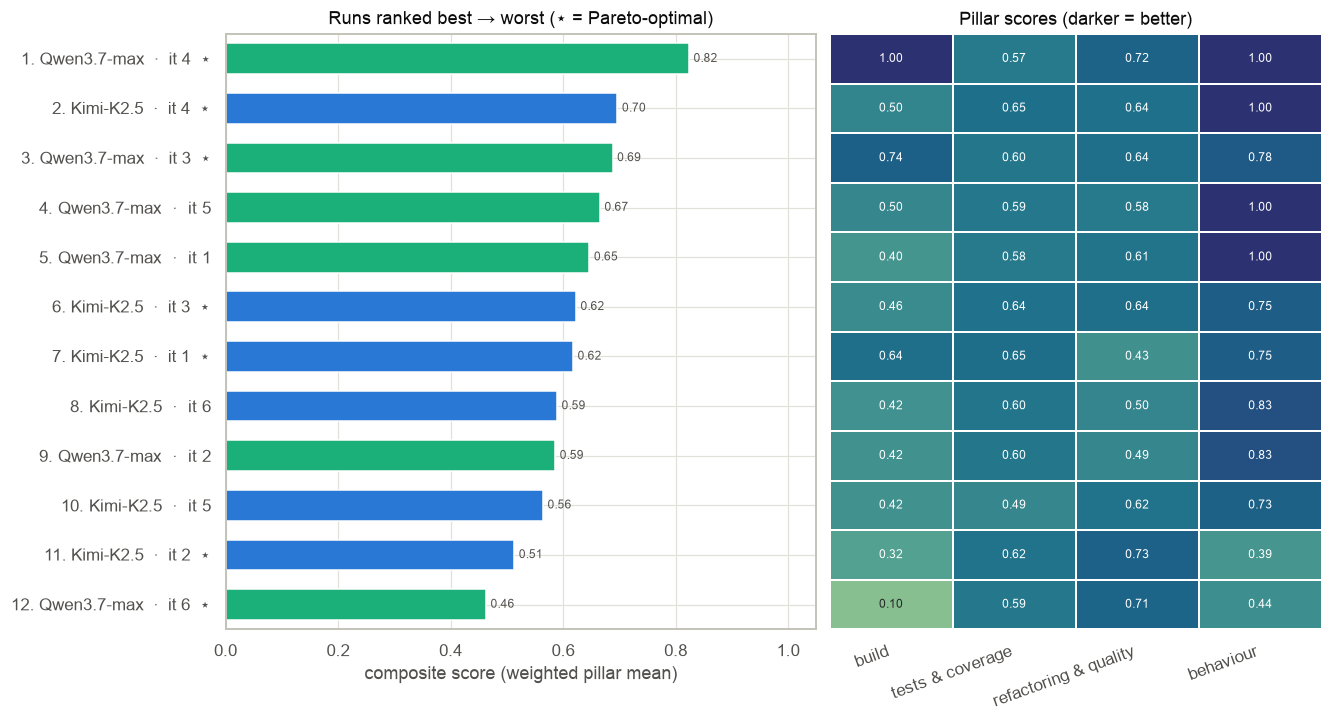

In [10]:
if summ.empty:
    print("No data for this section.")
else:
    from itertools import product

    LOW = "\u2193"  # suffix: lower raw value is better -> inverted (rel components)
    PILLAR_WEIGHTS = {"build": 1.0, "tests & coverage": 1.0,
                      "refactoring & quality": 1.0, "behaviour": 1.0}
    key = ["model", "iteration"]
    runs = summ.set_index(key)

    # -- derived criteria not in the master table ---------------------------
    FLAG = {"GREEN": 1.0, "YELLOW": 0.5, "RED": 0.0}

    def worst_flag_score(g):
        """Documented-threshold flag of each metric's worst type, averaged."""
        vals = []
        for col, flag_col, worst in (("mi", "mi_flag", "idxmin"),
                                     ("cc", "cc_flag", "idxmax"),
                                     ("coupling", "coupling_flag", "idxmax"),
                                     ("dit", "dit_flag", "idxmax")):
            s = g[col].dropna()
            if not s.empty:
                vals.append(FLAG.get(g.loc[getattr(s, worst)(), flag_col], 0.0))
        return np.mean(vals) if vals else np.nan

    mt = tdd.finals(data["metrics_types"])
    runs["worst_flag"] = (mt.groupby(key)[["mi", "mi_flag", "cc", "cc_flag",
                                           "coupling", "coupling_flag",
                                           "dit", "dit_flag"]].apply(worst_flag_score)
                          if not mt.empty else np.nan)

    # Absolute efficiency anchors: bounded 0-1 without min-max, so they stay
    # comparable across stories the way a rate does. 1 attempt -> 1.0.
    def efficiency(series, offset=0):
        v = pd.to_numeric(series, errors="coerce")
        return 1.0 / (v + offset)

    runs["build_efficiency"] = efficiency(runs["build_failed_execs"], offset=1)
    runs["green_efficiency"] = efficiency(runs["attempts_to_green"])
    runs["e2e_efficiency"] = efficiency(runs["e2e_attempts_to_pass"])

    # -- two-tier scoring ----------------------------------------------------
    def score(series, norm, invert=False):
        """abs: raw 0-1 anchor (clipped); rel: min-max within these runs
        (flat -> 0.5). Missing evidence always scores 0 (worst)."""
        v = pd.to_numeric(series, errors="coerce")
        if norm == "abs":
            return v.clip(0.0, 1.0).fillna(0.0)
        lo, hi = v.min(), v.max()
        if pd.isna(lo):
            return pd.Series(0.0, index=v.index)
        n = (v - lo) / (hi - lo) if hi > lo else v.where(v.isna(), 0.5)
        return (1.0 - n if invert else n).fillna(0.0)

    PILLARS = {
        "build": [
            ("build efficiency", "abs", runs["build_efficiency"]),
            (f"errors burned {LOW}", "rel", runs["build_errors_burned"]),
            (f"peak errors {LOW}", "rel", runs["build_peak_errors"]),
            (f"build warnings {LOW}", "rel", runs["build_warnings"]),
        ],
        "tests & coverage": [
            ("green efficiency", "abs", runs["green_efficiency"]),
            ("red-first discipline", "abs", runs["red_first"].astype(float)),
            ("line coverage", "abs", runs["line_rate"]),
            ("branch coverage", "abs", runs["branch_rate"]),
            ("layer balance", "abs", runs["layer_balance"]),
            (f"failures burned {LOW}", "rel", runs["test_failures_burned"]),
        ],
        "refactoring & quality": [
            ("% all-GREEN types", "abs", runs["pct_green_types"]),
            ("median MI", "abs", runs["median_mi"] / 100.0),
            ("worst-type MI", "abs", runs["min_mi"] / 100.0),
            ("worst-type flags", "abs", runs["worst_flag"]),
            (f"worst coupling {LOW}", "rel", runs["max_coupling"]),
            ("coupling reduced", "rel", runs["worst_coupling_drop"]),
            ("green share gained", "rel", runs["green_share_gain"]),
        ],
        "behaviour": [
            ("e2e efficiency", "abs", runs["e2e_efficiency"]),
            ("e2e probe pass rate", "abs", runs["e2e_probe_pass_rate"]),
            (f"e2e infra failures {LOW}", "rel", runs["e2e_infra_failures"]),
        ],
    }
    for pillar, comps in PILLARS.items():
        scored = pd.DataFrame({n: score(v, norm, n.endswith(LOW)) for n, norm, v in comps})
        runs[pillar] = scored.mean(axis=1)
    w = pd.Series(PILLAR_WEIGHTS)
    runs["composite"] = (runs[list(PILLARS)] * w).sum(axis=1) / w.sum()

    ranking = (runs.reset_index()
                   .sort_values(["composite", "model", "iteration"],
                                ascending=[False, True, True])
                   .reset_index(drop=True))
    ranking.index = pd.RangeIndex(1, len(ranking) + 1, name="rank")

    # -- weight-independent robustness --------------------------------------
    P = ranking[list(PILLARS)].to_numpy(dtype=float)
    n_runs, n_pillars = P.shape
    dominated = [any((P[j] >= P[i]).all() and (P[j] > P[i]).any()
                     for j in range(n_runs) if j != i) for i in range(n_runs)]
    ranking["pareto"] = ~np.array(dominated)

    # Deterministic simplex grid over however many pillars there are: each
    # weight 0.10-0.70 in 0.05 steps, keeping only combinations summing to 1.
    STEPS = [round(0.10 + 0.05 * k, 2) for k in range(13)]
    grid = np.array([c for c in product(STEPS, repeat=n_pillars)
                     if abs(sum(c) - 1.0) < 1e-9], dtype=float)
    top1 = np.zeros(n_runs)
    rank_lo, rank_hi = np.full(n_runs, n_runs), np.ones(n_runs)
    for wv in grid:
        comp = P @ wv
        order = np.argsort(-comp, kind="stable")
        rnk = np.empty(n_runs, dtype=int)
        rnk[order] = np.arange(1, n_runs + 1)
        top1[order[0]] += 1
        rank_lo, rank_hi = np.minimum(rank_lo, rnk), np.maximum(rank_hi, rnk)
    ranking["top1_share"] = top1 / len(grid)
    ranking["rank_range"] = [f"{int(lo)}\u2013{int(hi)}"
                             for lo, hi in zip(rank_lo, rank_hi)]

    # -- chart ---------------------------------------------------------------
    labels = [f"{r}. {m}  \u00b7  it {i}" + (r"  $\star$" if p else "")
              for r, m, i, p in zip(ranking.index, ranking["model"],
                                    ranking["iteration"], ranking["pareto"])]
    y = np.arange(n_runs) + 0.5                 # match heatmap row centers
    fig = plt.figure(figsize=(12, 0.42 * n_runs + 1.4))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

    ax1 = fig.add_subplot(gs[0])
    bars = ax1.barh(y, ranking["composite"], height=0.62,
                    color=[PAL[m] for m in ranking["model"]])
    ax1.bar_label(bars, fmt="%.2f", fontsize=8, color=tdd.INK["secondary"], padding=3)
    ax1.set_yticks(y, labels)
    ax1.set_ylim(n_runs, 0)                     # rank 1 on top
    ax1.set_xlim(0, 1.05)
    ax1.set_xlabel("composite score (weighted pillar mean)")
    ax1.set_title("Runs ranked best \u2192 worst ($\star$ = Pareto-optimal)")

    ax2 = fig.add_subplot(gs[1])
    sns.heatmap(ranking[list(PILLARS)].astype(float), cmap="crest", vmin=0, vmax=1,
                annot=True, fmt=".2f", linewidths=1, linecolor="white",
                yticklabels=False, cbar=False, annot_kws={"fontsize": 8}, ax=ax2)
    ax2.set_ylabel("")
    ax2.set_title("Pillar scores (darker = better)")
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

    detail_cols = ["build_failed_execs", "build_errors_burned", "build_peak_errors",
                   "build_warnings", "attempts_to_green", "test_failures_burned",
                   "red_first", "line_rate", "branch_rate",
                   "tests_per_intent", "layer_balance",
                   "median_mi", "min_mi", "max_coupling", "worst_flag",
                   "pct_green_types", "worst_coupling_drop", "green_share_gain",
                   "min_mi_gain", "e2e_attempts_to_pass", "e2e_probe_depth",
                   "e2e_infra_failures", "evidence_completeness", "source_lines"]
    front = ["model", "iteration", "composite"] + list(PILLARS) + \
            ["pareto", "top1_share", "rank_range"]
    display(ranking[front + detail_cols].round(3))


## Sanity checks

In [11]:
fb = tdd.finals(data["build"])
if not fb.empty:
    assert fb.groupby(["story", "model", "iteration"]).size().max() == 1
    assert fb["ts"].notna().all()
if not data["coverage"].empty:
    assert data["coverage"]["line_rate"].between(0, 1).all()

if summ.empty:
    print("no runs for this story yet — nothing to check beyond load integrity")
else:
    assert summ["iteration"].max() <= 6, "iterations beyond 6 must be excluded"
    assert len(ranking) == len(summ), "ranking must cover every (model, iteration) cell"
    assert ranking["composite"].between(0, 1).all(), "composite scores must stay in [0, 1]"
    assert bool(ranking["pareto"].iloc[0]), "weighted winner must be Pareto-optimal"
    assert abs(ranking["top1_share"].sum() - 1.0) < 1e-9, "top-1 shares must sum to 1"

    # Integrity guards -- these catch the failure mode where a join silently
    # matches nothing: the charts still render, but every value is empty.
    assert summ["model"].isin(HUE).all(), \
        "a model in the master table is not in the palette -- identity drift leaked through"
    for frame_name in ("build", "test", "metrics_types", "stages", "e2e"):
        frame = data[frame_name]
        if not frame.empty:
            assert frame["model"].isin(HUE).all(), f"{frame_name} carries an unknown model spelling"

assert drift.empty or drift["reconciles"].all(), \
    "some results are misfiled beyond what the canonical model key can reconcile"
scored = [m for m in tdd.METRIC_CATALOG if m in summ.columns]
assert len(scored) >= 15, "master table lost metrics -- check the loaders"
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings | "
      f"{len(dead)} metrics without signal | {len(scored)} metrics present")


sanity checks passed | 0 load warnings | 5 metrics without signal | 24 metrics present
